# 03 — Model Training

**Dataset:** `obesity_encoded.csv` (hasil preprocessing notebook 02)

**Task:** Multi-class Classification — 7 kelas obesity

**Target kolom:** `NObeyesdad`
```
0 → Insufficient_Weight   (272 samples)
1 → Normal_Weight         (287 samples)
2 → Obesity_Type_I        (351 samples)
3 → Obesity_Type_II       (297 samples)
4 → Obesity_Type_III      (324 samples)
5 → Overweight_Level_I    (290 samples)
6 → Overweight_Level_II   (290 samples)
```
**Feature kolom (21 total):**
`Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS, BMI, BMR, ActivityLevel, DailyCalorieTarget`

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics        import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Definisi Fitur

In [2]:
df = pd.read_csv('..\\data\\processed\\obesity_encoded.csv')
print(f'Shape: {df.shape}')

# Load metadata dari preprocessing
with open('..\\models\\model_meta.json') as f:
    meta = json.load(f)

TARGET   = meta['target']    # 'NObeyesdad'
FEATURES = meta['features']  # list 21 kolom
CLASSES  = meta['classes']   # 7 class labels (string)

print(f'Target  : {TARGET}')
print(f'Classes : {CLASSES}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Shape: (2087, 21)
Target  : NObeyesdad
Classes : ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Features (20): ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'BMI', 'BMR', 'ActivityLevel', 'DailyCalorieTarget']


In [3]:
X = df[FEATURES]
y = df[TARGET]

print('Class distribution (encoded):')
print(y.value_counts().sort_index())

# Load label encoder untuk nama kelas
with open('..\\models\\label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

le_target = le_dict[TARGET]
print('\nClass mapping (index → label):')
for i, cls in enumerate(le_target.classes_):
    count = (y == i).sum()
    print(f'  {i} → {cls:<25s} ({count} samples)')

Class distribution (encoded):
NObeyesdad
0    267
1    282
2    351
3    297
4    324
5    276
6    290
Name: count, dtype: int64

Class mapping (index → label):
  0 → Insufficient_Weight       (267 samples)
  1 → Normal_Weight             (282 samples)
  2 → Obesity_Type_I            (351 samples)
  3 → Obesity_Type_II           (297 samples)
  4 → Obesity_Type_III          (324 samples)
  5 → Overweight_Level_I        (276 samples)
  6 → Overweight_Level_II       (290 samples)


## 2. Train / Test Split

> Gunakan `stratify=y` agar distribusi 7 kelas proporsional di train & test,
> mengingat dataset cukup balanced (272–351 per kelas).

Train : (1669, 20) | 1669 samples
Test  : (418, 20)  | 418 samples


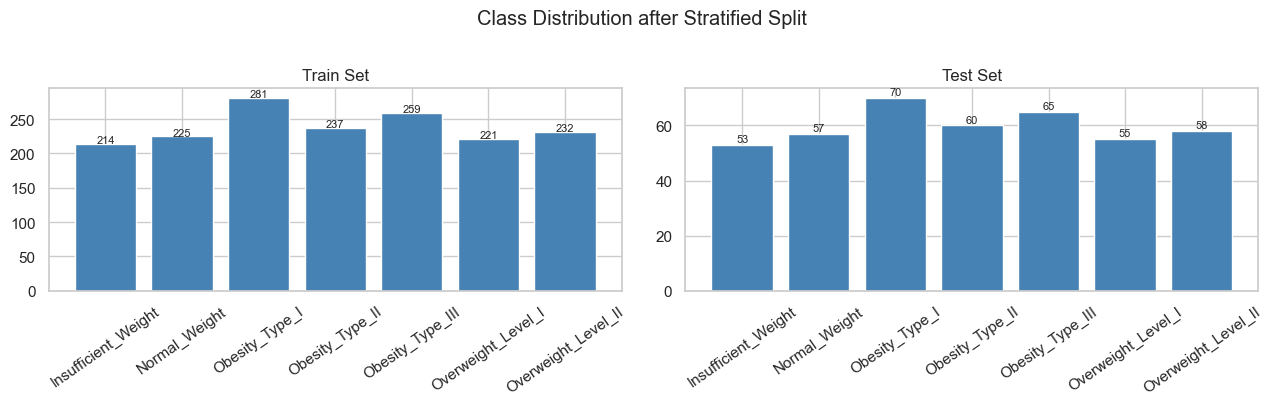

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # penting untuk 7-class balanced dataset
)

print(f'Train : {X_train.shape} | {len(y_train)} samples')
print(f'Test  : {X_test.shape}  | {len(y_test)} samples')

# Verifikasi distribusi kelas di split
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split_y, title in zip(axes, [y_train, y_test], ['Train Set', 'Test Set']):
    counts = split_y.value_counts().sort_index()
    ax.bar([CLASSES[i] for i in counts.index], counts.values, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=8)
plt.suptitle('Class Distribution after Stratified Split', y=1.01)
plt.tight_layout()
plt.show()

## 3. Baseline — Bandingkan 3 Model

Gunakan **Stratified 5-Fold CV** agar setiap fold menjaga proporsi 7 kelas.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_baseline = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',  # eksplisit untuk 7 kelas
        solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
}

cv_results = {}
print(f'{"Model":<25s}  {"Mean Acc":>10s}  {"Std":>8s}  {"Mean F1-macro":>14s}')
print('-' * 65)

for name, model in models_baseline.items():
    acc_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro',  n_jobs=-1)
    cv_results[name] = {
        'mean_acc': acc_scores.mean(),
        'std_acc':  acc_scores.std(),
        'mean_f1':  f1_scores.mean()
    }
    print(f'{name:<25s}  {acc_scores.mean():.4f}      {acc_scores.std():.4f}    {f1_scores.mean():.4f}')

Model                        Mean Acc       Std   Mean F1-macro
-----------------------------------------------------------------
Logistic Regression        0.9113      0.0163    0.9076
Random Forest              0.9880      0.0019    0.9874
Gradient Boosting          0.9790      0.0027    0.9786


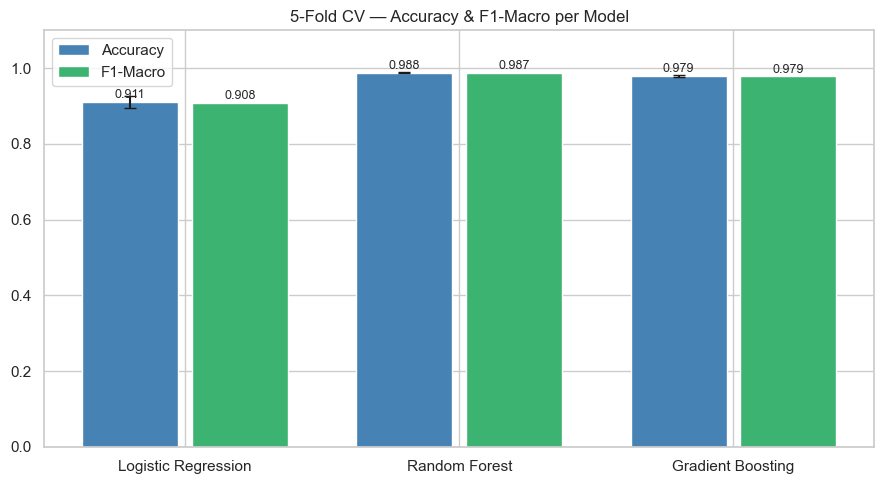


→ Best baseline: Random Forest


In [6]:
# Visualisasi perbandingan
names    = list(cv_results.keys())
acc_vals = [cv_results[n]['mean_acc'] for n in names]
f1_vals  = [cv_results[n]['mean_f1']  for n in names]
std_vals = [cv_results[n]['std_acc']  for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - 0.2, acc_vals, 0.35, label='Accuracy', color='steelblue',  yerr=std_vals, capsize=4)
bars2 = ax.bar(x + 0.2, f1_vals,  0.35, label='F1-Macro',  color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_title('5-Fold CV — Accuracy & F1-Macro per Model')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../models/baseline_comparison.png', dpi=150)
plt.show()

best_baseline = max(cv_results, key=lambda k: cv_results[k]['mean_f1'])
print(f'\n→ Best baseline: {best_baseline}')

## 4. Hyperparameter Tuning — Random Forest

> Random Forest dipilih karena:
> - Robust terhadap campuran fitur numerik + encoded kategorik (21 fitur)
> - Dataset ~2087 baris — tidak overfit mudah
> - Memberikan feature importance yang langsung bisa diinterpretasi
>
> Jika CV Gradient Boosting lebih unggul, ganti blok ini dengan GradientBoostingClassifier.

In [7]:
from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearch lebih efisien dari GridSearch untuk ruang param besar
param_dist = {
    'n_estimators':      [100, 200, 300, 400],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],  # default sqrt sudah baik untuk klasifikasi
    'class_weight':      [None, 'balanced'] # test apakah balanced membantu
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    rf, param_dist,
    n_iter=30,               # coba 30 kombinasi acak
    cv=skf,
    scoring='f1_macro',      # optimasi F1-macro karena 7 kelas
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print('\nBest params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV F1-macro: {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:
  n_estimators: 400
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 20
  class_weight: balanced
Best CV F1-macro: 0.9906


## 5. Evaluasi Final Model di Test Set

In [8]:
best_model = search.best_estimator_

y_pred      = best_model.predict(X_test)
test_acc    = accuracy_score(y_test, y_pred)
test_f1     = f1_score(y_test, y_pred, average='macro')

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1-Macro : {test_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

Test Accuracy : 0.9928
Test F1-Macro : 0.9923

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       1.00      0.98      0.99        57
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      0.96      0.98        55
Overweight_Level_II       0.97      1.00      0.98        58

           accuracy                           0.99       418
          macro avg       0.99      0.99      0.99       418
       weighted avg       0.99      0.99      0.99       418



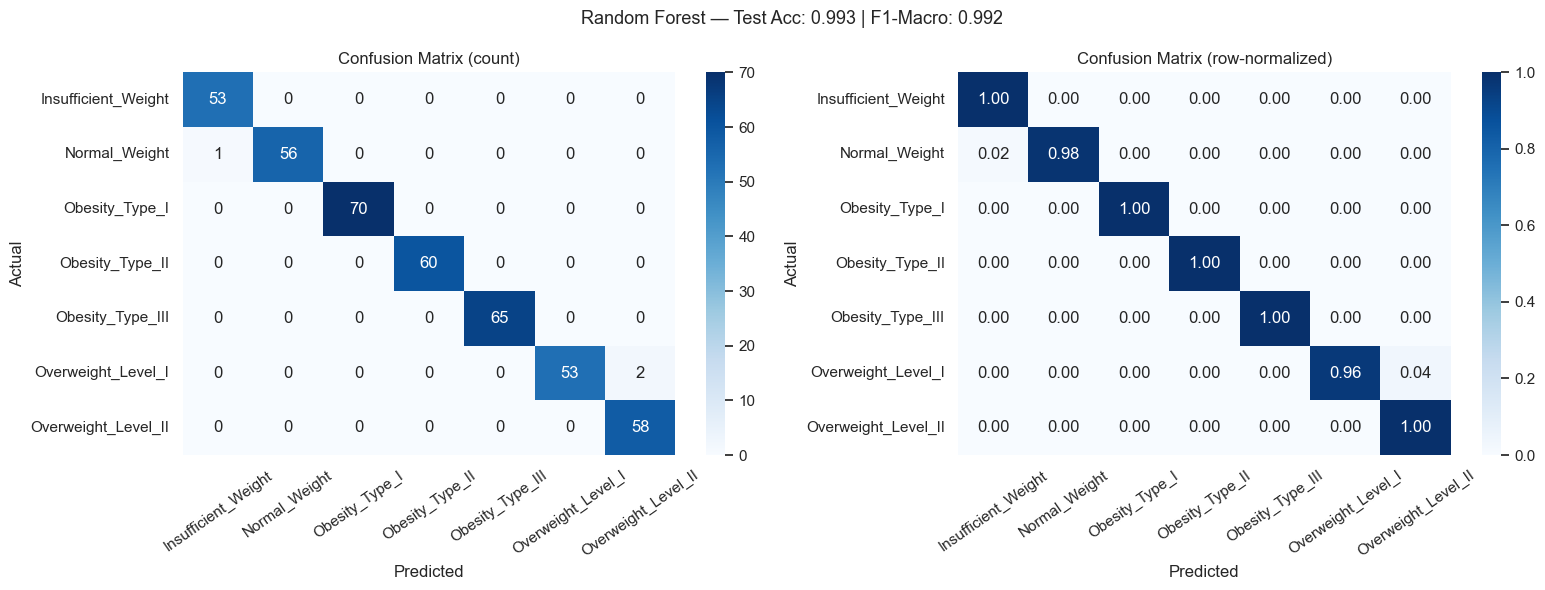

In [9]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (count)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=35)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'Random Forest — Test Acc: {test_acc:.3f} | F1-Macro: {test_f1:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()

## 6. Feature Importance

> Analisis ini penting untuk validasi bahwa model belajar dari fitur yang logis secara domain.
> Ekspektasi: `Weight`, `Height`, `BMI` harus muncul sebagai fitur terpenting.

Top 10 Most Important Features:
           feature  importance
               BMI    0.368534
            Weight    0.179138
               BMR    0.097128
              FCVC    0.046153
            Height    0.044692
               Age    0.043155
            Gender    0.042940
DailyCalorieTarget    0.038321
               NCP    0.020640
               FAF    0.019517


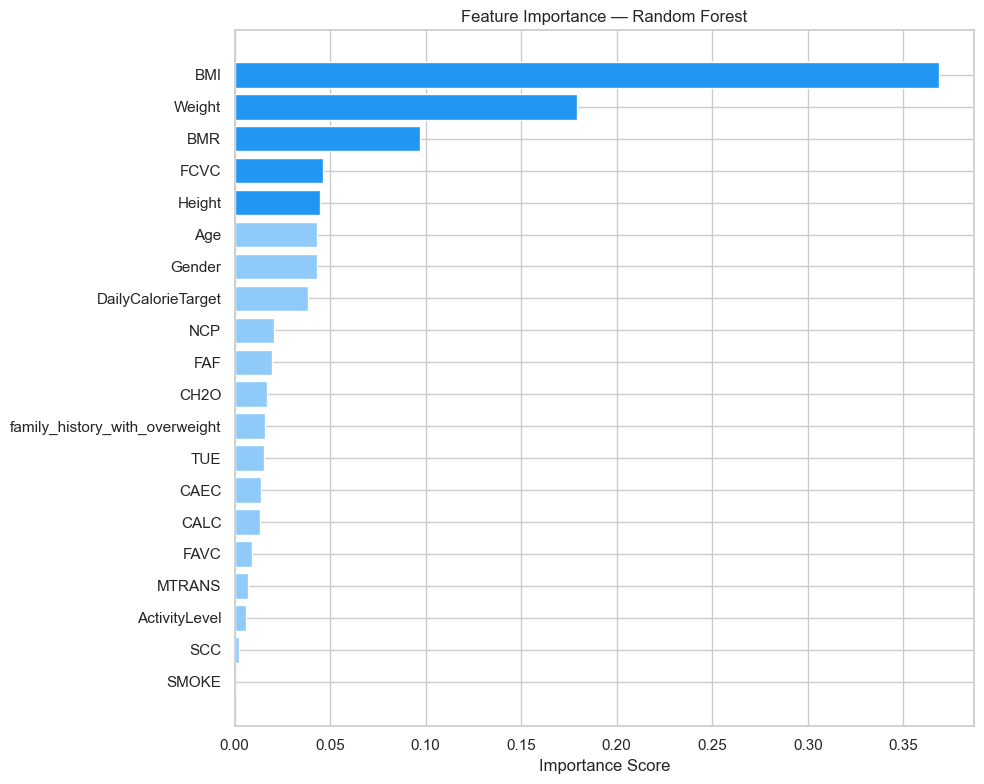


Top 5 features: ['BMI', 'Weight', 'BMR', 'FCVC', 'Height']
Overlap dengan expected domain features: ['BMI', 'Weight', 'BMR', 'Height']
✅ Model belajar dari fitur yang logis secara domain.


In [10]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 10 Most Important Features:')
print(feat_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2196F3' if i < 5 else '#90CAF9' for i in range(len(feat_df))]
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest')

# Annotate top 5
for i, (imp, feat) in enumerate(zip(
    feat_df['importance'].values[:5][::-1],
    feat_df['feature'].values[:5][::-1]
)):
    idx = len(feat_df) - 1 - list(feat_df['feature'][::-1]).index(feat)

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150)
plt.show()

# Validasi domain knowledge
top5 = feat_df['feature'].head(5).tolist()
expected_top = ['Weight', 'Height', 'BMI', 'BMR', 'Age']
print(f'\nTop 5 features: {top5}')
overlap = [f for f in top5 if f in expected_top]
print(f'Overlap dengan expected domain features: {overlap}')
if len(overlap) >= 3:
    print('✅ Model belajar dari fitur yang logis secara domain.')
else:
    print('⚠️  Perlu investigasi — fitur top tidak sesuai ekspektasi domain.')

## 7. Simpan Model & Update Metadata

In [11]:
# Simpan model
with open('../models/obesity_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Saved: models/obesity_model.pkl')

# Update model_meta.json dengan hasil training
meta.update({
    'model_type':     type(best_model).__name__,
    'best_params':    search.best_params_,
    'test_accuracy':  round(test_acc, 4),
    'test_f1_macro':  round(test_f1,  4),
    'cv_f1_macro':    round(search.best_score_, 4),
    'n_train':        len(X_train),
    'n_test':         len(X_test),
    'feature_importance': dict(zip(
        feat_df['feature'].tolist(),
        feat_df['importance'].round(4).tolist()
    ))
})

with open('../models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Updated: models/model_meta.json')

print('\n=== Training Summary ===')
print(f'  Model       : {meta["model_type"]}')
print(f'  Best params : {meta["best_params"]}')
print(f'  CV F1-macro : {meta["cv_f1_macro"]}')
print(f'  Test Acc    : {meta["test_accuracy"]}')
print(f'  Test F1     : {meta["test_f1_macro"]}')

Saved: models/obesity_model.pkl
Updated: models/model_meta.json

=== Training Summary ===
  Model       : RandomForestClassifier
  Best params : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
  CV F1-macro : 0.9906
  Test Acc    : 0.9928
  Test F1     : 0.9923


## 8. Quick Sanity Check — Inference Simulasi

> Verifikasi pipeline inference end-to-end sebelum masuk ke notebook 04.

In [12]:
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

def quick_predict(raw_input: dict) -> dict:
    """
    raw_input: nilai asli dari user (belum di-encode).
    Kolom wajib sesuai 17 kolom original obesity dataset:
      Gender, Age, Height, Weight,
      family_history_with_overweight, FAVC, FCVC, NCP,
      CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS
    """
    row = raw_input.copy()

    # Feature engineering (sama seperti preprocessing)
    h   = row['Height']
    w   = row['Weight']
    age = row['Age']
    g   = str(row['Gender']).lower()

    row['BMI'] = round(w / (h ** 2), 2)

    h_cm = h * 100
    if 'female' in g:
        row['BMR'] = round(447.593 + (9.247*w) + (3.098*h_cm) - (4.330*age), 2)
    else:
        row['BMR'] = round(88.362 + (13.397*w) + (4.799*h_cm) - (5.677*age), 2)

    row['ActivityLevel']       = min(int(round(row['FAF'])), 3)
    activity_mult              = {0: 1.2, 1: 1.375, 2: 1.55, 3: 1.725}
    row['DailyCalorieTarget']  = int(row['BMR'] * activity_mult[row['ActivityLevel']])

    # Encode
    df_row = pd.DataFrame([row])
    for col, le in le_dict.items():
        if col in df_row.columns and col != TARGET:
            df_row[col] = le.transform(df_row[col].astype(str))

    # Reorder kolom sesuai FEATURES, scale, predict
    df_row = df_row.reindex(columns=FEATURES, fill_value=0)
    df_scaled = scaler.transform(df_row)

    pred_idx   = best_model.predict(df_scaled)[0]
    pred_proba = best_model.predict_proba(df_scaled)[0]
    pred_label = le_target.inverse_transform([pred_idx])[0]

    return {
        'obesity_class':       pred_label,
        'confidence_pct':      round(float(pred_proba.max()) * 100, 1),
        'bmi':                 row['BMI'],
        'bmr':                 row['BMR'],
        'daily_calorie_target': row['DailyCalorieTarget'],
        'all_probabilities': {
            cls: round(float(p)*100, 1)
            for cls, p in zip(CLASSES, pred_proba)
        }
    }

# ── Test Cases ────────────────────────────────────────────────────
test_cases = [
    ('Normal Weight Male 25yo', {
        'Gender': 'Male', 'Age': 25, 'Height': 1.75, 'Weight': 70,
        'family_history_with_overweight': 'no', 'FAVC': 'no',
        'FCVC': 2, 'NCP': 3, 'CAEC': 'Sometimes', 'SMOKE': 'no',
        'CH2O': 2, 'SCC': 'no', 'FAF': 2, 'TUE': 1,
        'CALC': 'Sometimes', 'MTRANS': 'Public_Transportation'
    }),
    ('Obesity Type I Female 35yo', {
        'Gender': 'Female', 'Age': 35, 'Height': 1.60, 'Weight': 100,
        'family_history_with_overweight': 'yes', 'FAVC': 'yes',
        'FCVC': 1, 'NCP': 4, 'CAEC': 'Frequently', 'SMOKE': 'no',
        'CH2O': 1, 'SCC': 'no', 'FAF': 0, 'TUE': 3,
        'CALC': 'Frequently', 'MTRANS': 'Automobile'
    }),
    ('Insufficient Weight Female 20yo', {
        'Gender': 'Female', 'Age': 20, 'Height': 1.65, 'Weight': 45,
        'family_history_with_overweight': 'no', 'FAVC': 'no',
        'FCVC': 3, 'NCP': 2, 'CAEC': 'no', 'SMOKE': 'no',
        'CH2O': 3, 'SCC': 'yes', 'FAF': 1, 'TUE': 0,
        'CALC': 'no', 'MTRANS': 'Walking'
    }),
]

for label, inp in test_cases:
    result = quick_predict(inp)
    print(f'\n── {label} ──')
    print(f'  Predicted class  : {result["obesity_class"]}')
    print(f'  Confidence       : {result["confidence_pct"]}%')
    print(f'  BMI              : {result["bmi"]}')
    print(f'  Daily Calories   : {result["daily_calorie_target"]} kcal')


── Normal Weight Male 25yo ──
  Predicted class  : Normal_Weight
  Confidence       : 94.8%
  BMI              : 22.86
  Daily Calories   : 2672 kcal

── Obesity Type I Female 35yo ──
  Predicted class  : Obesity_Type_I
  Confidence       : 36.4%
  BMI              : 39.06
  Daily Calories   : 2059 kcal

── Insufficient Weight Female 20yo ──
  Predicted class  : Insufficient_Weight
  Confidence       : 89.3%
  BMI              : 16.53
  Daily Calories   : 1771 kcal
